In [45]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import StepLR

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATv2Conv, Linear, to_hetero

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Hardware acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Hardware Accelerator: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")


Active Hardware Accelerator: cuda
GPU Name: NVIDIA GeForce RTX 3050


In [46]:
# Load datasets
tcga_df = pd.read_csv('../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../dataset/weseq_processed_with_id_and_race_V2.csv')

# Drop identifier if present
if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

# Feature definitions
categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 
                'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
                'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

print("Data successfully loaded and feature dimensions aligned.")
print("\nTCGA (first 10 rows):")
display(tcga_df.head(10))
print("\nCGGA (first 10 rows):")
display(cgga_df.head(10))

# Class distribution
print('\nGlioma grade class information (0 = "LGG"; 1 = "GBM")\nOriginal Target Distribution:')
print('TCGA\n', tcga_df['Grade'].value_counts())
print('CGGA\n', cgga_df['Grade'].value_counts())

Data successfully loaded and feature dimensions aligned.

TCGA (first 10 rows):


,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,33.21,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,1,35.19,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,1,44.65,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,1,33.96,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,87.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



CGGA (first 10 rows):


,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,1,51,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,42,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,33,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,43,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,25,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,38,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,45,2,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
7,0,1,40,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,43,2,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
9,0,0,31,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Glioma grade class information (0 = "LGG"; 1 = "GBM")
Original Target Distribution:
TCGA
 Grade
0    487
1    352
Name: count, dtype: int64
CGGA
 Grade
0    184
1    102
Name: count, dtype: int64


Initializing SDV Metadata and CTGAN Synthesizer...
Synthesizing 135 targeted minority samples using CTGAN on GPU...


Sampling conditions: 100%|██████████| 135/135 [00:00<00:00, 855.98it/s]


CTGAN Synthesis Complete. TCGA Matrix successfully rebalanced.


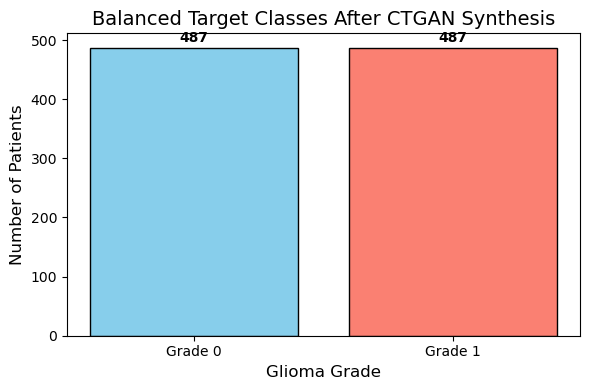

In [47]:
# 3. Balance TCGA using CTGAN

print("Initializing SDV Metadata and CTGAN Synthesizer...")
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(tcga_df)

# Force categorical dtype for all gene and clinical columns
for col in categorical_columns + gene_columns:
    metadata.update_column(column_name=col, sdtype='categorical')

class_distributions = tcga_df['Grade'].value_counts()
majority_class = class_distributions.idxmax()
minority_class = class_distributions.idxmin()
samples_needed = class_distributions[majority_class] - class_distributions[minority_class]

print(f"Synthesizing {samples_needed} targeted minority samples using CTGAN on GPU...")

synthesizer = CTGANSynthesizer(metadata, epochs=150, batch_size=50, verbose=False, cuda=True)
synthesizer.fit(tcga_df)

minority_condition = Condition(num_rows=samples_needed, column_values={'Grade': minority_class})
synthetic_samples = synthesizer.sample_from_conditions(conditions=[minority_condition])

tcga_balanced_df = pd.concat([tcga_df, synthetic_samples], ignore_index=True)
print("CTGAN Synthesis Complete. TCGA Matrix successfully rebalanced.")

# Visualize balanced classes
class_counts = tcga_balanced_df['Grade'].value_counts().sort_index()
plt.figure(figsize=(6,4))
bars = plt.bar(['Grade 0', 'Grade 1'], class_counts.values, color=['skyblue', 'salmon'], edgecolor='black')
plt.title("Balanced Target Classes After CTGAN Synthesis", fontsize=14)
plt.xlabel("Glioma Grade", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5, f'{int(height)}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

Constructing Topological Bipartite Graphs...
Graphs constructed and moved to VRAM.

--- TCGA Graph ---
Patients: 974, Genes: 20
Forward edges (G→P): 2297
Reverse edges (P→G): 2297
Class distribution: [487 487]
--- CGGA Graph ---
Patients: 286, Genes: 20
Forward edges (G→P): 582
Reverse edges (P→G): 582
Class distribution: [184 102]


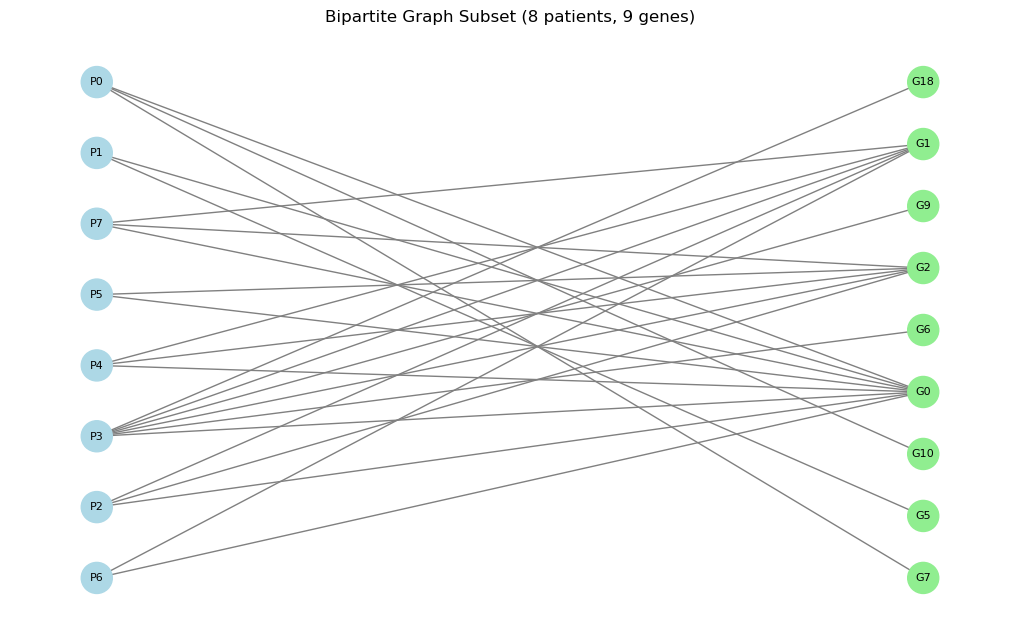

In [48]:
# 4. Construct Bipartite Heterogeneous Graph (with reverse edges)

def construct_bipartite_heterograph(df):
    """
    Build a heterogeneous graph with Patient and Gene nodes.
    Patient features: Gender, Race (categorical), Age (normalized)
    Gene features: one‑hot identity vectors
    Edges: 
        - Gene -> Patient (mutates) 
        - Patient -> Gene (mutated_by)  – added to ensure both node types receive updates
    """
    graph = HeteroData()
    
    # Normalize age
    scaler = StandardScaler()
    age_normalized = scaler.fit_transform(df[['Age_at_diagnosis']])
    
    # Patient features: Gender, Race, Age
    clinical_features = df[['Gender', 'Race']].values
    patient_features = np.hstack([clinical_features, age_normalized])
    graph['Patient'].x = torch.tensor(patient_features, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    
    # Gene nodes: identity matrix (one‑hot per gene)
    num_genes = len(gene_columns)
    graph['Gene'].x = torch.eye(num_genes, dtype=torch.float)
    
    # Edge lists (source gene index, target patient index)
    edge_src_genes = []
    edge_dst_patients = []
    
    for p_idx, row in df.iterrows():
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:          # gene mutated in this patient
                edge_src_genes.append(g_idx)
                edge_dst_patients.append(p_idx)
    
    # Forward edges: Gene -> Patient
    graph['Gene', 'mutates', 'Patient'].edge_index = torch.tensor(
        [edge_src_genes, edge_dst_patients], dtype=torch.long
    )
    
    # Reverse edges: Patient -> Gene (so that genes also receive messages)
    graph['Patient', 'mutated_by', 'Gene'].edge_index = torch.tensor(
        [edge_dst_patients, edge_src_genes], dtype=torch.long
    )
    
    return graph

print("Constructing Topological Bipartite Graphs...")
tcga_graph = construct_bipartite_heterograph(tcga_balanced_df).to(device)
cgga_graph = construct_bipartite_heterograph(cgga_df).to(device)
print("Graphs constructed and moved to VRAM.")

# Display graph statistics
print("\n--- TCGA Graph ---")
print(f"Patients: {tcga_graph['Patient'].x.shape[0]}, Genes: {tcga_graph['Gene'].x.shape[0]}")
print(f"Forward edges (G→P): {tcga_graph['Gene', 'mutates', 'Patient'].edge_index.shape[1]}")
print(f"Reverse edges (P→G): {tcga_graph['Patient', 'mutated_by', 'Gene'].edge_index.shape[1]}")
print("Class distribution:", torch.bincount(tcga_graph['Patient'].y).cpu().numpy())

print("--- CGGA Graph ---")
print(f"Patients: {cgga_graph['Patient'].x.shape[0]}, Genes: {cgga_graph['Gene'].x.shape[0]}")
print(f"Forward edges (G→P): {cgga_graph['Gene', 'mutates', 'Patient'].edge_index.shape[1]}")
print(f"Reverse edges (P→G): {cgga_graph['Patient', 'mutated_by', 'Gene'].edge_index.shape[1]}")
print("Class distribution:", torch.bincount(cgga_graph['Patient'].y).cpu().numpy())

# Optional: visualize a small subset (unchanged)
def plot_graph_subset(graph, num_patients=10):
    edge_index = graph['Gene', 'mutates', 'Patient'].edge_index.cpu()
    unique_patients = torch.unique(edge_index[1])[:num_patients]
    mask = torch.isin(edge_index[1], unique_patients)
    sub_edge = edge_index[:, mask]
    
    G = nx.Graph()
    for p in unique_patients.tolist():
        G.add_node(f"P{p}", bipartite=0)
    genes_in_sub = torch.unique(sub_edge[0]).tolist()
    for g in genes_in_sub:
        G.add_node(f"G{g}", bipartite=1)
    for i in range(sub_edge.shape[1]):
        G.add_edge(f"G{sub_edge[0,i].item()}", f"P{sub_edge[1,i].item()}")
    
    plt.figure(figsize=(10,6))
    pos = nx.bipartite_layout(G, [n for n in G.nodes if n.startswith('P')])
    nx.draw(G, pos, with_labels=True, 
            node_color=['lightblue' if n.startswith('P') else 'lightgreen' for n in G.nodes],
            node_size=500, font_size=8, edge_color='gray')
    plt.title(f"Bipartite Graph Subset ({len(unique_patients)} patients, {len(genes_in_sub)} genes)")
    plt.show()

# Uncomment to see a sample graph
plot_graph_subset(tcga_graph, num_patients=8)

In [49]:
# ## 5. Split TCGA into Train / Test (80/20)

def split_graph(graph, train_ratio=0.8, seed=42):
    """Add train_mask and test_mask to Patient nodes."""
    num_patients = graph['Patient'].x.shape[0]
    indices = torch.randperm(num_patients, generator=torch.Generator().manual_seed(seed))
    train_size = int(train_ratio * num_patients)
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]
    
    graph['Patient'].train_mask = torch.zeros(num_patients, dtype=torch.bool)
    graph['Patient'].test_mask = torch.zeros(num_patients, dtype=torch.bool)
    graph['Patient'].train_mask[train_indices] = True
    graph['Patient'].test_mask[test_indices] = True
    return graph

tcga_graph = split_graph(tcga_graph, train_ratio=0.8, seed=42)
print(f"TCGA split: {tcga_graph['Patient'].train_mask.sum().item()} train, "
      f"{tcga_graph['Patient'].test_mask.sum().item()} test")

# %% [markdown]
# ## 6. Define GNN Model

# %%
class HomogeneousGATv2(torch.nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=8, dropout_rate=0.5):
        super().__init__()
        self.dropout_rate = dropout_rate
        
        self.conv1 = GATv2Conv((-1, -1), hidden_dim, heads=num_heads, add_self_loops=False)
        self.skip1 = Linear(-1, hidden_dim * num_heads)
        
        self.conv2 = GATv2Conv((-1, -1), hidden_dim, heads=num_heads, add_self_loops=False)
        self.skip2 = Linear(-1, hidden_dim * num_heads)
        
        self.conv3 = GATv2Conv((-1, -1), out_dim, heads=1, concat=False, add_self_loops=False)
        self.skip3 = Linear(-1, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index) + self.skip1(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        x = self.conv2(x, edge_index) + self.skip2(x)
        x = F.leaky_relu(x, negative_slope=0.2)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        x = self.conv3(x, edge_index) + self.skip3(x)
        return x

# Convert to heterogeneous model
base_model = HomogeneousGATv2(hidden_dim=32, out_dim=2, num_heads=8)
hetero_model = to_hetero(base_model, tcga_graph.metadata(), aggr='sum').to(device)

# Dummy forward to initialize lazy parameters
with torch.no_grad():
    hetero_model(tcga_graph.x_dict, tcga_graph.edge_index_dict)

print("Heterogeneous GATv2 Architecture Initialized on GPU.")
print(f"Total parameters: {sum(p.numel() for p in hetero_model.parameters())}")

TCGA split: 779 train, 195 test
Heterogeneous GATv2 Architecture Initialized on GPU.
Total parameters: 419092


In [50]:
# 7. Loss, Optimizer, and Scheduler
# Weighted loss to compensate for original imbalance (used even after balancing for safety)
penalty_weight = class_distributions[majority_class] / class_distributions[minority_class]
cost_matrix = torch.tensor([1.0, penalty_weight], dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=cost_matrix)

optimizer = torch.optim.Adam(hetero_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

In [51]:
# 8. Training Loop with Internal Test and External Validation
epochs = 150
train_losses = []
train_accs = []
test_accs = []
cgga_aucs = []

print("Starting Training...")
hetero_model.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    
    out_dict = hetero_model(tcga_graph.x_dict, tcga_graph.edge_index_dict)
    patient_logits = out_dict['Patient']
    
    # Loss only on training nodes
    loss = criterion(patient_logits[tcga_graph['Patient'].train_mask],
                     tcga_graph['Patient'].y[tcga_graph['Patient'].train_mask])
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    train_losses.append(loss.item())
    
    # Evaluate on train and test (TCGA internal)
    with torch.no_grad():
        preds = patient_logits.argmax(dim=1)
        train_acc = (preds[tcga_graph['Patient'].train_mask] == tcga_graph['Patient'].y[tcga_graph['Patient'].train_mask]).float().mean().item()
        test_acc = (preds[tcga_graph['Patient'].test_mask] == tcga_graph['Patient'].y[tcga_graph['Patient'].test_mask]).float().mean().item()
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        # Evaluate on CGGA (external)
        cgga_out = hetero_model(cgga_graph.x_dict, cgga_graph.edge_index_dict)['Patient']
        cgga_probs = F.softmax(cgga_out, dim=1)[:, 1].cpu().numpy()
        cgga_auc = roc_auc_score(cgga_graph['Patient'].y.cpu().numpy(), cgga_probs)
        cgga_aucs.append(cgga_auc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | CGGA AUC: {cgga_auc:.4f}")

print("Training complete.")

Starting Training...
Epoch  10/150 | Loss: 0.4702 | Train Acc: 0.7869 | Test Acc: 0.7590 | CGGA AUC: 0.7128
Epoch  20/150 | Loss: 0.4409 | Train Acc: 0.8036 | Test Acc: 0.7590 | CGGA AUC: 0.6923
Epoch  30/150 | Loss: 0.4262 | Train Acc: 0.8370 | Test Acc: 0.7795 | CGGA AUC: 0.7746
Epoch  40/150 | Loss: 0.4536 | Train Acc: 0.8177 | Test Acc: 0.7744 | CGGA AUC: 0.7384
Epoch  50/150 | Loss: 0.4208 | Train Acc: 0.8254 | Test Acc: 0.7897 | CGGA AUC: 0.7637
Epoch  60/150 | Loss: 0.3975 | Train Acc: 0.8370 | Test Acc: 0.7949 | CGGA AUC: 0.7737
Epoch  70/150 | Loss: 0.3927 | Train Acc: 0.8344 | Test Acc: 0.7897 | CGGA AUC: 0.8013
Epoch  80/150 | Loss: 0.4009 | Train Acc: 0.8472 | Test Acc: 0.7897 | CGGA AUC: 0.7843
Epoch  90/150 | Loss: 0.3941 | Train Acc: 0.8395 | Test Acc: 0.8000 | CGGA AUC: 0.7868
Epoch 100/150 | Loss: 0.3918 | Train Acc: 0.8395 | Test Acc: 0.7795 | CGGA AUC: 0.7876
Epoch 110/150 | Loss: 0.4177 | Train Acc: 0.8113 | Test Acc: 0.7795 | CGGA AUC: 0.7768
Epoch 120/150 | Loss: 

In [52]:
# 9. Final Evaluation on All Splits

hetero_model.eval()
with torch.no_grad():
    # TCGA final predictions
    tcga_out = hetero_model(tcga_graph.x_dict, tcga_graph.edge_index_dict)['Patient']
    tcga_probs = F.softmax(tcga_out, dim=1).cpu().numpy()
    tcga_preds = tcga_out.argmax(dim=1).cpu().numpy()
    tcga_labels = tcga_graph['Patient'].y.cpu().numpy()
    tcga_train_mask = tcga_graph['Patient'].train_mask.cpu().numpy()
    tcga_test_mask = tcga_graph['Patient'].test_mask.cpu().numpy()
    
    # Train metrics
    train_auc = roc_auc_score(tcga_labels[tcga_train_mask], tcga_probs[tcga_train_mask, 1])
    train_acc = (tcga_preds[tcga_train_mask] == tcga_labels[tcga_train_mask]).mean()
    
    # Test metrics (internal)
    test_auc = roc_auc_score(tcga_labels[tcga_test_mask], tcga_probs[tcga_test_mask, 1])
    test_acc = (tcga_preds[tcga_test_mask] == tcga_labels[tcga_test_mask]).mean()
    
    # CGGA external
    cgga_out = hetero_model(cgga_graph.x_dict, cgga_graph.edge_index_dict)['Patient']
    cgga_probs = F.softmax(cgga_out, dim=1).cpu().numpy()
    cgga_preds = cgga_out.argmax(dim=1).cpu().numpy()
    cgga_labels = cgga_graph['Patient'].y.cpu().numpy()
    cgga_auc = roc_auc_score(cgga_labels, cgga_probs[:, 1])
    cgga_acc = (cgga_preds == cgga_labels).mean()

print("="*50)
print("FINAL EVALUATION")
print("="*50)
print(f"TCGA Train   - Acc: {train_acc:.4f}, AUC: {train_auc:.4f}")
print(f"TCGA Test    - Acc: {test_acc:.4f}, AUC: {test_auc:.4f}")
print(f"CGGA External- Acc: {cgga_acc:.4f}, AUC: {cgga_auc:.4f}")
print("="*50)

FINAL EVALUATION
TCGA Train   - Acc: 0.8254, AUC: 0.9004
TCGA Test    - Acc: 0.8000, AUC: 0.8679
CGGA External- Acc: 0.4825, AUC: 0.7694


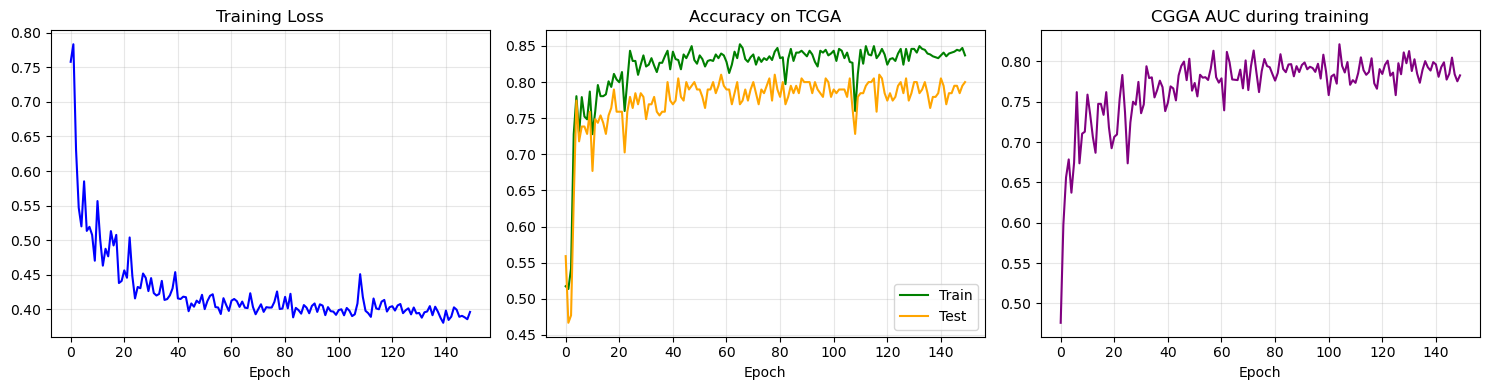

In [53]:
# 10.1 Training curves
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(train_losses, color='blue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label='Train', color='green')
axes[1].plot(test_accs, label='Test', color='orange')
axes[1].set_title('Accuracy on TCGA')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(cgga_aucs, color='purple')
axes[2].set_title('CGGA AUC during training')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

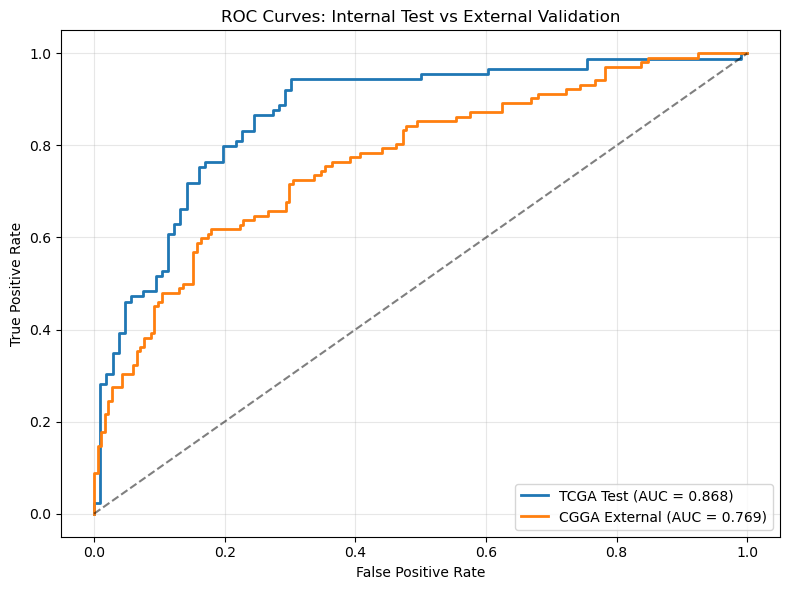

In [54]:
# 10.2 ROC Curves
fpr_test, tpr_test, _ = roc_curve(tcga_labels[tcga_test_mask], tcga_probs[tcga_test_mask, 1])
fpr_cgga, tpr_cgga, _ = roc_curve(cgga_labels, cgga_probs[:, 1])

plt.figure(figsize=(8,6))
plt.plot(fpr_test, tpr_test, label=f'TCGA Test (AUC = {test_auc:.3f})', linewidth=2)
plt.plot(fpr_cgga, tpr_cgga, label=f'CGGA External (AUC = {cgga_auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Internal Test vs External Validation')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

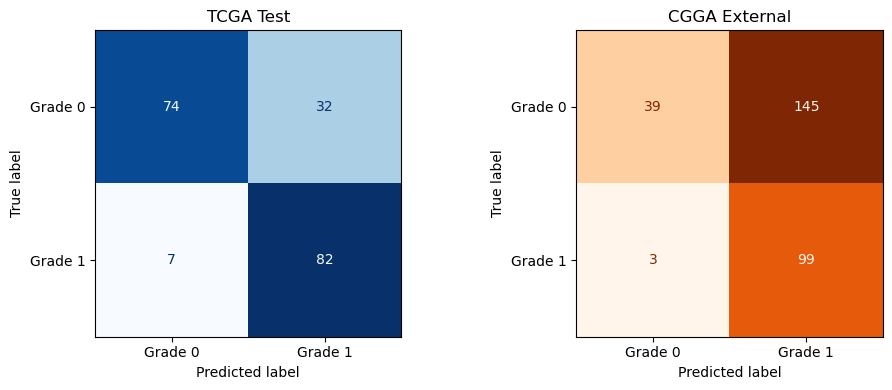

In [55]:
# 10.3 Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10,4))
# TCGA test
cm_test = confusion_matrix(tcga_labels[tcga_test_mask], tcga_preds[tcga_test_mask])
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=['Grade 0', 'Grade 1'])
disp_test.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('TCGA Test')
# CGGA
cm_cgga = confusion_matrix(cgga_labels, cgga_preds)
disp_cgga = ConfusionMatrixDisplay(cm_cgga, display_labels=['Grade 0', 'Grade 1'])
disp_cgga.plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('CGGA External')
plt.tight_layout()
plt.show()

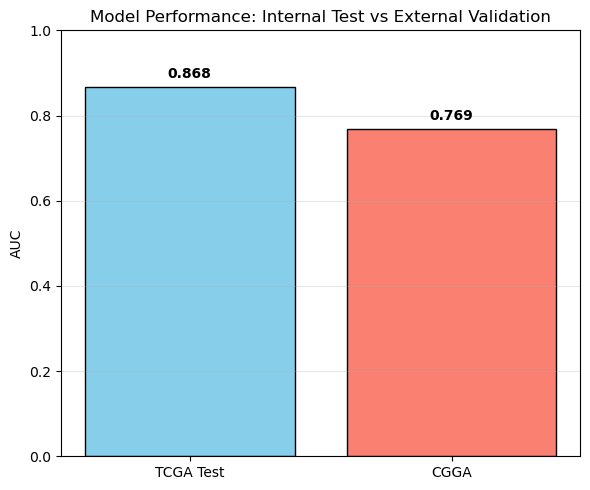

In [56]:
# 10.4 AUC comparison bar chart
plt.figure(figsize=(6,5))
bars = plt.bar(['TCGA Test', 'CGGA'], [test_auc, cgga_auc], color=['skyblue', 'salmon'], edgecolor='black')
plt.ylim(0,1)
plt.ylabel('AUC')
plt.title('Model Performance: Internal Test vs External Validation')
for bar, val in zip(bars, [test_auc, cgga_auc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 11. (Optional) Save Model

#torch.save(hetero_model.state_dict(), 'trainnedmodels/glioma_gnn_model_Version1.pth')
#("Model saved.")

Model saved.
